A(L) = 0.90540  →  ΔE_pred = 1.48932
13,824 basis states  (grid 24³)

Eigenvalues:
E0 = 1.309212
E1 = 2.200370
ΔE_num = 0.891158
Ratio  ΔE_num / ΔE_pred = 0.598


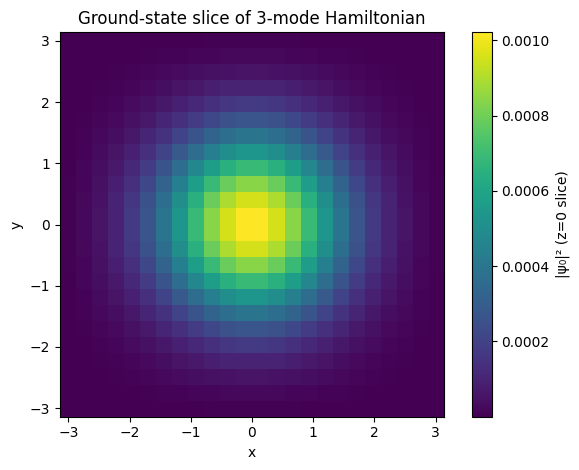

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1) Physical inputsa
# ------------------------------------------------------------------
L_phys = 0.90        # fm
g2_L   = 2.012
A_L    = 0.5 * g2_L * L_phys
ΔE_pred = A_L * (np.pi**2 / 6.0)

print(f"A(L) = {A_L:.5f}  →  ΔE_pred = {ΔE_pred:.5f}")

# ------------------------------------------------------------------
# 2) Grid parameters
# ------------------------------------------------------------------
N      = 24          # grid points per axis (try 32 if RAM permits)
x_max  = np.pi       # fundamental domain for sin² potential: [-π, π]

grid = np.linspace(-x_max, x_max, N)
dx = grid[1] - grid[0]

# 1‑D Laplacian (Neumann BC) ------------------------
main = -2.0*np.ones(N)
off  =  1.0*np.ones(N-1)
lap1d = sp.diags([off, main, off], [-1,0,1]) / dx**2

I = sp.identity(N, format='csr')

# 3‑D Laplacian: Δ = lap_x ⊗ I ⊗ I + I ⊗ lap_y ⊗ I + I ⊗ I ⊗ lap_z
lap3d = (sp.kron(sp.kron(lap1d, I), I) +
         sp.kron(sp.kron(I, lap1d), I) +
         sp.kron(sp.kron(I, I), lap1d))

# Potential  V = ½ g²L [ sin²(x/2)+sin²(y/2)+sin²(z/2) ]
X, Y, Z = np.meshgrid(grid, grid, grid, indexing='ij')
V = 0.5 * g2_L * L_phys * (np.sin(X/2.0)**2 + np.sin(Y/2.0)**2 + np.sin(Z/2.0)**2)
V_diag = sp.diags(V.ravel())

# Hamiltonian  H = -½ g² Δ + V
H = (-0.5 * g2_L) * lap3d + V_diag

print(f"{H.shape[0]:,d} basis states  (grid {N}³)")

# ------------------------------------------------------------------
# 3) Lowest two eigenvalues
# ------------------------------------------------------------------
evals, evecs = spla.eigsh(H, k=2, which='SM')   # smallest magnitude
evals = np.sort(evals)
E0, E1 = evals
ΔE_num = E1 - E0

print(f"\nEigenvalues:")
print(f"E0 = {E0:.6f}")
print(f"E1 = {E1:.6f}")
print(f"ΔE_num = {ΔE_num:.6f}")
print(f"Ratio  ΔE_num / ΔE_pred = {ΔE_num/ΔE_pred:.3f}")

# ------------------------------------------------------------------
# 4)  (Optional) show a slice of the ground-state density
# ------------------------------------------------------------------
idx_mid = N // 2
psi0 = evecs[:,0].reshape((N,N,N))
plt.imshow(np.abs(psi0[:,:,idx_mid])**2,
           extent=[-x_max, x_max, -x_max, x_max],
           origin='lower', cmap='viridis')
plt.colorbar(label='|ψ₀|² (z=0 slice)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Ground‑state slice of 3‑mode Hamiltonian')
plt.tight_layout(); plt.show()